In [2]:
from dotenv import load_dotenv
from agents import Agent, Runner, trace, function_tool, OpenAIChatCompletionsModel, input_guardrail, GuardrailFunctionOutput
from openai.types.responses import ResponseTextDeltaEvent
import asyncio
from agents import Agent, Runner, trace, function_tool
from typing import Dict, List, Optional
import json
import pandas as pd
from datetime import datetime
import os
import nest_asyncio
from IPython.display import Markdown, display

import nest_asyncio
import asyncio
import matplotlib.pyplot as plt
import asyncio
from IPython.display import display, Markdown
from collections import Counter

In [3]:
nest_asyncio.apply()

In [4]:
load_dotenv(override=True)

True

In [17]:
import json
import pandas as pd
import os

# Global inventory dataframe
inventory_df = None

def load_data_new():
    """
    Loads vehicle inventory data from CAR_UNIQUE_DATA.json
    into the global inventory_df.
    """

    global inventory_df

    DATA_DIR = "/Users/karthikathota/Documents/Final-Yr-Project/Api/data"
    FILE_NAME = "CAR_UNIQUE_DATA.json"
    FILE_PATH = os.path.join(DATA_DIR, FILE_NAME)

    try:
        # -------------------------
        # Validate file existence
        # -------------------------
        if not os.path.exists(FILE_PATH):
            print(f"❌ Data file not found: {FILE_PATH}")
            return False

        # -------------------------
        # Load JSON
        # -------------------------
        with open(FILE_PATH, "r", encoding="utf-8") as f:
            data = json.load(f)

        # -------------------------
        # Convert to DataFrame
        # -------------------------
        inventory_df = pd.DataFrame(data)

        if inventory_df.empty:
            print("⚠️ Inventory loaded but dataset is empty.")
            return False

        print(f"✅ Inventory loaded successfully: {len(inventory_df)} vehicles")
        return True

    except json.JSONDecodeError as e:
        print(f"❌ JSON parsing error: {e}")
        return False

    except Exception as e:
        print(f"❌ Failed to load inventory data: {e}")
        return False


# Main Code

### Budget Agent

In [8]:
@function_tool
def search_vehicles_by_budget(
    max_budget: int,
    min_budget: int = 0,
    limit: int = 10,
    max_per_make: int = 2
):
    global inventory_df

    if inventory_df is None:
        if not load_data_new():
            return []

    def get_price(row):
        if isinstance(row.get("msrp"), (int, float)):
            return row["msrp"]
        if isinstance(row.get("price"), (int, float)):
            return row["price"]
        return None

    df = inventory_df.copy()
    df["computed_price"] = df.apply(get_price, axis=1)

    df = df[
        (df["computed_price"].notnull()) &
        (df["computed_price"] >= min_budget) &
        (df["computed_price"] <= max_budget)
    ]

    results = []
    make_count = {}

    for _, row in df.iterrows():
        make = row.get("make")
        if not make:
            continue

        make_count.setdefault(make, 0)
        if make_count[make] < max_per_make:
            results.append(row.drop("computed_price").to_dict())
            make_count[make] += 1

        if len(results) >= limit:
            break

    return results



### Family Agent

In [9]:
@function_tool
def search_vehicles_by_type(vehicle_type: str, limit: int = 20):
    global inventory_df

    if inventory_df is None:
        load_data_new()

    keywords = {
    "suv": ["suv"],
        "crossover": ["crossover"],
        "minivan": ["minivan", "van"],
        "sedan": ["sedan"]
    }

    terms = keywords.get(vehicle_type.lower(), [])
    if not terms:
        return []

    mask = inventory_df["description"].fillna("").str.lower().apply(
        lambda x: any(term in x for term in terms)
    )

    return inventory_df[mask].head(limit).to_dict("records")




### Eco-Frinedly Agent

In [10]:
@function_tool
def search_eco_vehicles(
    eco_type: str = "any",   # electric | hybrid | any
    limit: int = 20
):
    """
    STRICT eco-friendly vehicle search.
    Returns ONLY:
    - Fully Electric Vehicles (EV)
    - Full Hybrids / Plug-in Hybrids

    EXCLUDES:
    - Fuel-efficient petrol/diesel
    - Mild hybrids
    - Marketing terms like 'efficient'
    """

    global inventory_df
    if inventory_df is None:
        load_data_new()

    df = inventory_df.copy()

    submodel = df["submodel"].fillna("").str.lower()
    desc = df["description"].fillna("").str.lower()
    model = df["model"].fillna("")

    # -------------------------
    # STRICT ELECTRIC VEHICLES
    # -------------------------
    electric = (
        submodel.str.contains(r"\belectric\b|\bev\b") |
        model.str.contains(r"\bEV\b|Electric", regex=True) |
        desc.str.contains(r"\bfully electric\b|\bev\b|\belectric vehicle\b")
    )

    # -------------------------
    # STRICT HYBRID VEHICLES
    # -------------------------
    hybrid = (
        desc.str.contains(r"\bhybrid\b|\bplug-in hybrid\b|\bphev\b") &
        ~desc.str.contains(r"\bmild hybrid\b")   # EXCLUDE mild hybrids
    )

    # -------------------------
    # FILTER BY TYPE
    # -------------------------
    if eco_type == "electric":
        mask = electric
    elif eco_type == "hybrid":
        mask = hybrid
    else:
        mask = electric | hybrid

    return df[mask].head(limit).to_dict("records")






### All 3 agents instances

In [11]:
budget_recommendation_agent = Agent(
    name="Budget Recommendation Agent",
    instructions="""
You are a STRICTLY data-grounded budget-focused vehicle agent.

RULES:
1. You MUST call `search_vehicles_by_budget`.
2. No prior knowledge allowed.
3. Use ONLY tool output.
4. Max 2 vehicles per make.
5. No results → say so clearly.
6. Never output raw JSON.

BUDGET MAPPING:
- MAX only → max_budget
- MIN only → min_budget + very high max_budget
- RANGE → both min_budget and max_budget
- Single unclear number → treat as max_budget

OUTPUT:
Summarize with make, model, year, price.
""",
    tools=[search_vehicles_by_budget],
    model="gpt-4o-mini"
)

In [12]:

family_vehicle_agent = Agent(
    name="Family Vehicle Agent",
    instructions="""
You are a STRICTLY data-grounded family vehicle agent.

RULES:
1. Focus on SUVs, crossovers, minivans.
2. MUST call `search_vehicles_by_type`.
3. If budget is mentioned → MUST call `search_vehicles_by_budget`.

BUDGET MAPPING:
- MAX → max_budget
- MIN → min_budget + high max_budget
- RANGE → both

CONSTRAINTS:
- Tool output only
- Max 2 vehicles per make
- Max 10 vehicles
- No raw JSON

OUTPUT:
Make, model, year, price.
""",
    tools=[search_vehicles_by_type, search_vehicles_by_budget],
    model="gpt-4o-mini"
)

In [13]:
eco_vehicle_agent = Agent(
    name="Eco-Friendly Vehicle Agent",
    instructions="""
You are a STRICT eco-friendly vehicle agent.

MANDATORY RULES:

1. You MUST call `search_eco_vehicles` FIRST to get ONLY eco-friendly vehicles.
2. If a budget is mentioned in the query, you MUST ALSO call
   `search_vehicles_by_budget` to enforce the budget constraint.
3. The FINAL recommendations must satisfy BOTH:
   - Eco constraint (EV or full/plug-in hybrid only)
   - Budget constraint (if provided)
4. You must NEVER recommend:
   - Petrol or diesel vehicles
   - Fuel-efficient cars
   - Mild hybrids
5. You must use ONLY tool outputs.
6. Maximum 10 vehicles.
7. NEVER output raw JSON.

PROCESS TO FOLLOW:
- Step 1: Retrieve eco-friendly vehicles using `search_eco_vehicles`
- Step 2: If budget is present, filter results using `search_vehicles_by_budget`
- Step 3: Return the intersection of both results

OUTPUT FORMAT:
Make, model, year, price.
""",
    tools=[
        search_eco_vehicles,
        search_vehicles_by_budget
    ],
    model="gpt-4o-mini"
)

### Agent to Tools Conversion

In [14]:
budget_tool = budget_recommendation_agent.as_tool(
    tool_name="budget_specialist",
    tool_description="Get budget-focused vehicle recommendations and value analysis"
)


family_tool = family_vehicle_agent.as_tool(
    tool_name="family_specialist", 
    tool_description="Get family-oriented vehicle recommendations focusing on safety and practicality"
)


eco_tool = eco_vehicle_agent.as_tool(
    tool_name="eco_specialist", 
    tool_description="Get eco-friendly vehicle recommendations prioritizing electric and hybrid options"
)

### Orchestration Agent

In [22]:
# =========================
# ADVANCED VEHICLE SALES ORCHESTRATOR
# =========================

vehicle_recommendation_agent = Agent(
    name="Vehicle Sales & Recommendation Manager",
    instructions="""
You are an expert car salesman and vehicle recommendation orchestrator.

Your goal is to guide customers from vague intent to confident vehicle selection
using ONLY data-backed specialist tools.

────────────────────────
CORE RESPONSIBILITIES
────────────────────────
1. Interpret user intent even when it is incomplete, vague, or informal.
2. Identify ALL relevant priorities:
   - Budget (minimum, maximum, or range)
   - Family size / space needs
   - Eco-friendliness
   - Practicality vs comfort
   - General browsing vs purchase-ready
3. Route the request to the correct specialist agent(s).
4. Combine results across agents when necessary.
5. Present a confident, helpful recommendation like a real salesman.

────────────────────────
INTENT INTERPRETATION RULES
────────────────────────
• If the user mentions money in ANY form → treat it as budget intent.
• If the user says:
  - "family", "kids", "space", "comfort" → Family Agent
  - "electric", "hybrid", "EV", "eco" → Eco Agent
  - "cheap", "best value", "affordable" → Budget Agent
• If multiple intents appear → call MULTIPLE agents.
• If intent is unclear → start with Family + Budget agents.

────────────────────────
BUDGET HANDLING (CRITICAL)
────────────────────────
• "Under / below / max" → max_budget
• "Above / minimum / at least" → min_budget
• "Between X and Y" → range
• Single unclear number → treat as max_budget

Budget interpretation is done by specialists, NOT you.

────────────────────────
RESPONSE RULES
────────────────────────
1. Recommend exactly 2–3 vehicles.
2. For EACH vehicle:
   - Make, model, year
   - Price
   - Why it suits the customer
3. Explicitly state which specialist agent found it.
4. If no perfect match exists:
   - Explain trade-offs honestly
   - Suggest the closest alternatives
5. NEVER invent data.
6. NEVER output raw JSON.
7. Be friendly, confident, and professional.

────────────────────────
SALESMAN BEHAVIOR
────────────────────────
• Speak like a human, not a chatbot.
• Reassure the buyer.
• Point out practical benefits.
• End with clear next steps:
  - test drive
  - compare trims
  - finalize shortlist

You are allowed to ask ONE short clarifying question
ONLY if the request is extremely ambiguous.
""",
    tools=[
        budget_tool,
        family_tool,
        eco_tool
    ],
    model="gpt-4o-mini"
)


# =========================
# TEST THE ORCHESTRATION AGENT
# =========================
async def test_vehicle_recommendation_agent():
    with trace("Testing Vehicle Recommendation Manager"):
        result = await Runner.run(
            vehicle_recommendation_agent,
            "Give me 3 family friendly cars that are in between 60000 and 80000 dollars"
        )
        # Display the final output
        display(Markdown(result.final_output))

# Run the test
asyncio.run(test_vehicle_recommendation_agent())

Here are three excellent family-friendly vehicles within your budget of $60,000 to $80,000, recommended for their space, comfort, and safety features:

### 1. Audi A6 Quattro
- **Year:** 2015
- **Price:** $60,100
- **Why it suits:** This luxury sedan offers ample space, high-quality interior materials, and advanced safety features, making it comfortable for family trips.

### 2. Cadillac Escalade
- **Year:** 2015
- **Price:** $71,695
- **Why it suits:** The Escalade is known for its spaciousness and premium features. With three rows of seating, it's perfect for families requiring extra room and luxury.

### 3. Genesis G90
- **Year:** 2017
- **Price:** $68,100
- **Why it suits:** The Genesis G90 combines style with comfort, boasting an incredibly quiet cabin and plenty of luxury features, making it a great option for family travel.

### Summary:
- **Specialist Agent:** Both Family and Budget specialists provided these options, ensuring they are practical yet fit within your financial range.

Would you like to know more details about these vehicles, or perhaps schedule a test drive?

In [20]:
# ============================================================
# FULL CSR PIPELINE – SAFE, CORRECT, PAPER-READY
# ============================================================

import os
import json
import pandas as pd
import asyncio
from tabulate import tabulate

# ============================================================
# GLOBAL INVENTORY
# ============================================================

inventory_df = None


# ============================================================
# LOAD DATA FUNCTION (UPDATED PATH)
# ============================================================

def load_data_new():
    global inventory_df

    DATA_DIR = "/Users/karthikathota/Documents/Final-Yr-Project/Api/data"
    FILE_NAME = "CAR_UNIQUE_DATA.json"
    FILE_PATH = os.path.join(DATA_DIR, FILE_NAME)

    if not os.path.exists(FILE_PATH):
        raise FileNotFoundError(f"Data file not found: {FILE_PATH}")

    with open(FILE_PATH, "r", encoding="utf-8") as f:
        data = json.load(f)

    inventory_df = pd.DataFrame(data)

    if inventory_df.empty:
        raise ValueError("Inventory loaded but is empty")

    print(f"✅ Loaded {len(inventory_df)} vehicles into inventory")
    return True


# ============================================================
# RAW FUNCTIONS (CSR-SAFE — NOT TOOLS)
# ============================================================

def search_eco_vehicles_raw(eco_type="any", limit=50):
    global inventory_df
    if inventory_df is None:
        load_data_new()

    df = inventory_df.copy()

    submodel = df["submodel"].fillna("").str.lower()
    desc = df["description"].fillna("").str.lower()
    model = df["model"].fillna("")

    electric = (
        submodel.str.contains(r"\belectric\b|\bev\b") |
        model.str.contains(r"\bEV\b|Electric", regex=True) |
        desc.str.contains(r"\bfully electric\b|\belectric vehicle\b|\bev\b")
    )

    hybrid = (
        desc.str.contains(r"\bhybrid\b|\bplug-in hybrid\b|\bphev\b") &
        ~desc.str.contains(r"\bmild hybrid\b")
    )

    if eco_type == "electric":
        mask = electric
    elif eco_type == "hybrid":
        mask = hybrid
    else:
        mask = electric | hybrid

    return df[mask].head(limit).to_dict("records")


def search_vehicles_by_budget_raw(min_budget, max_budget, limit=10, max_per_make=2):
    global inventory_df
    if inventory_df is None:
        load_data_new()

    def get_price(row):
        if isinstance(row.get("msrp"), (int, float)):
            return row["msrp"]
        if isinstance(row.get("price"), (int, float)):
            return row["price"]
        return None

    df = inventory_df.copy()
    df["computed_price"] = df.apply(get_price, axis=1)

    df = df[
        (df["computed_price"].notnull()) &
        (df["computed_price"] >= min_budget) &
        (df["computed_price"] <= max_budget)
    ]

    results = []
    make_count = {}

    for _, row in df.iterrows():
        make = row.get("make")
        if not make:
            continue

        make_count.setdefault(make, 0)
        if make_count[make] < max_per_make:
            results.append(row.drop("computed_price").to_dict())
            make_count[make] += 1

        if len(results) >= limit:
            break

    return results


# ============================================================
# CSR CONSTRAINT EVALUATION
# ============================================================

def evaluate_constraints(final_results, min_budget, max_budget):
    rows = []

    # Eco constraint
    eco_ok = all(
        ("electric" in str(v.get("submodel", "")).lower()) or
        ("ev" in str(v.get("model", "")).lower()) or
        ("hybrid" in str(v.get("description", "")).lower())
        for v in final_results
    )
    rows.append(["Eco Constraint", "EV / Full Hybrid only", "YES" if eco_ok else "NO"])

    # Min budget
    min_ok = all(v.get("msrp", v.get("price", 0)) >= min_budget for v in final_results)
    rows.append(["Budget Constraint", f"≥ {min_budget}", "YES" if min_ok else "NO"])

    # Max budget
    max_ok = all(v.get("msrp", v.get("price", 0)) <= max_budget for v in final_results)
    rows.append(["Budget Constraint", f"≤ {max_budget}", "YES" if max_ok else "NO"])

    # Quantity
    qty_ok = len(final_results) == 3
    rows.append(["Quantity Constraint", "Exactly 3 vehicles", "YES" if qty_ok else "NO"])

    # Make diversity
    make_count = {}
    for v in final_results:
        make_count[v["make"]] = make_count.get(v["make"], 0) + 1
    diversity_ok = all(c <= 2 for c in make_count.values())
    rows.append(["Make Diversity", "≤ 2 vehicles per make", "YES" if diversity_ok else "NO"])

    return rows


# ============================================================
# CSR RUNNER (ORCHESTRATOR + EVALUATION)
# ============================================================

async def csr_run_and_evaluate():
    query = "Give me 3 eco friendly cars that are in between 80000 and 100000 dollars"

    # Run orchestrator (for realism / trace / paper)
    await Runner.run(vehicle_recommendation_agent, query)

    # Ground-truth evaluation
    eco_results = search_eco_vehicles_raw(limit=50)
    budget_results = search_vehicles_by_budget_raw(
        min_budget=80000,
        max_budget=100000,
        limit=10
    )

    # Intersection
    final_results = [
        v for v in eco_results
        if any(
            v["make"] == b["make"] and
            v["model"] == b["model"] and
            v.get("year") == b.get("year")
            for b in budget_results
        )
    ][:3]

    csr_table = evaluate_constraints(
        final_results,
        min_budget=80000,
        max_budget=100000
    )

    # Print CSR table
    print("\nCSR – CONSTRAINT SATISFACTION TABLE\n")
    print(tabulate(
        csr_table,
        headers=["Constraint Category", "Requirement", "Satisfied"],
        tablefmt="github"
    ))

    # Summary
    satisfied = sum(1 for r in csr_table if r[-1] == "YES")
    print("\nCSR SUMMARY\n")
    print(tabulate(
        [
            ["Total Constraints", len(csr_table)],
            ["Satisfied", satisfied],
            ["Violated", len(csr_table) - satisfied],
            ["Satisfaction Rate", f"{(satisfied / len(csr_table)) * 100:.1f}%"]
        ],
        tablefmt="github"
    ))


# ============================================================
# RUN CSR
# ============================================================

asyncio.run(csr_run_and_evaluate())


✅ Loaded 710 vehicles into inventory

CSR – CONSTRAINT SATISFACTION TABLE

| Constraint Category   | Requirement           | Satisfied   |
|-----------------------|-----------------------|-------------|
| Eco Constraint        | EV / Full Hybrid only | YES         |
| Budget Constraint     | ≥ 80000               | YES         |
| Budget Constraint     | ≤ 100000              | YES         |
| Quantity Constraint   | Exactly 3 vehicles    | NO          |
| Make Diversity        | ≤ 2 vehicles per make | YES         |

CSR SUMMARY

|-------------------|-------|
| Total Constraints | 5     |
| Satisfied         | 4     |
| Violated          | 1     |
| Satisfaction Rate | 80.0% |


⏱ Measuring agent latencies...

Latency Results (seconds):
Budget Agent: 6.144s
Family Agent: 7.935s
Eco Agent: 7.319s
Orchestrator Agent: 13.502s


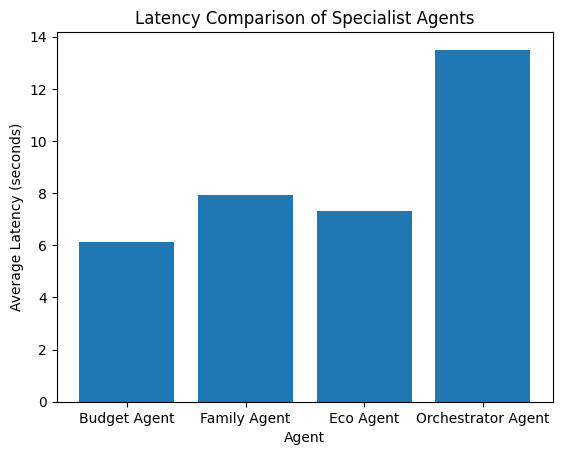

In [23]:
# ============================================================
# SPECIALIST AGENT LATENCY BENCHMARK
# ============================================================

import time
import asyncio
import matplotlib.pyplot as plt

# ============================================================
# BENCHMARK FUNCTION
# ============================================================

async def measure_agent_latency(agent, query, runs=3):
    """
    Measures average latency of an agent over N runs
    """
    latencies = []

    for _ in range(runs):
        start = time.perf_counter()
        await Runner.run(agent, query)
        end = time.perf_counter()
        latencies.append(end - start)

    return sum(latencies) / len(latencies)


# ============================================================
# RUN LATENCY EXPERIMENT
# ============================================================

async def run_latency_experiment():

    query = "Give me 3 eco friendly cars that are in between 80000 and 100000 dollars"

    print("⏱ Measuring agent latencies...\n")

    budget_latency = await measure_agent_latency(
        budget_recommendation_agent,
        query
    )

    family_latency = await measure_agent_latency(
        family_vehicle_agent,
        query
    )

    eco_latency = await measure_agent_latency(
        eco_vehicle_agent,
        query
    )

    orchestrator_latency = await measure_agent_latency(
        vehicle_recommendation_agent,
        query
    )

    agent_names = [
        "Budget Agent",
        "Family Agent",
        "Eco Agent",
        "Orchestrator Agent"
    ]

    latencies = [
        budget_latency,
        family_latency,
        eco_latency,
        orchestrator_latency
    ]

    print("Latency Results (seconds):")
    for name, latency in zip(agent_names, latencies):
        print(f"{name}: {latency:.3f}s")

    # ========================================================
    # PLOT LATENCY GRAPH
    # ========================================================

    plt.figure()
    plt.bar(agent_names, latencies)
    plt.xlabel("Agent")
    plt.ylabel("Average Latency (seconds)")
    plt.title("Latency Comparison of Specialist Agents")
    plt.show()


# ============================================================
# RUN
# ============================================================

asyncio.run(run_latency_experiment())


### System Latency

In [3]:
# =========================
# SYSTEM LATENCY MEASUREMENT – SINGLE CELL (ROBUST + JUPYTER SAFE)
# =========================

import os
import json
import time
import pandas as pd
from dataclasses import dataclass
from IPython.display import display

# -------------------------
# GLOBAL DATA
# -------------------------
inventory_df = None

# -------------------------
# LOAD DATA (GUARDED)
# -------------------------
def load_data_new():
    global inventory_df
    file_path = os.path.join("data", "carapi_unique_inventory.json")
    if not os.path.exists(file_path):
        inventory_df = pd.DataFrame([])  # safe empty fallback
        return False

    with open(file_path, "r") as f:
        inventory_data = json.load(f)

    inventory_df = pd.DataFrame(inventory_data)
    return True

# -------------------------
# LATENCY TRACKER
# -------------------------
@dataclass
class LatencyMetrics:
    Tanalysis: float = 0.0
    Trouting: float = 0.0
    Texecution: float = 0.0
    Tsynthesis: float = 0.0

    @property
    def total(self):
        return self.Tanalysis + self.Trouting + self.Texecution + self.Tsynthesis

latency = LatencyMetrics()

# -------------------------
# BUDGET SEARCH (TIMED + SAFE)
# -------------------------
def timed_search_vehicles_by_budget(max_budget, min_budget=0, limit=5, max_per_make=2):
    global inventory_df, latency
    start = time.perf_counter()

    if inventory_df is None:
        load_data_new()

    if inventory_df is None or inventory_df.empty:
        latency.Texecution = (time.perf_counter() - start) * 1000
        return []

    def get_price(row):
        if isinstance(row.get("msrp"), (int, float)):
            return row["msrp"]
        if isinstance(row.get("price"), (int, float)):
            return row["price"]
        return None

    df = inventory_df.copy()
    df["computed_price"] = df.apply(get_price, axis=1)

    df = df[
        (df["computed_price"].notnull()) &
        (df["computed_price"] >= min_budget) &
        (df["computed_price"] <= max_budget)
    ]

    results = []
    make_count = {}

    for _, row in df.iterrows():
        make = row.get("make")
        if not make:
            continue

        make_count.setdefault(make, 0)
        if make_count[make] < max_per_make:
            results.append(row.drop("computed_price").to_dict())
            make_count[make] += 1

        if len(results) >= limit:
            break

    latency.Texecution = (time.perf_counter() - start) * 1000
    return results

# -------------------------
# RUN QUERY (SYNC, SIMULATED LLM)
# -------------------------
query = "Find cars under $60,000. Return exactly 5 cars."

t0 = time.perf_counter()
time.sleep(0.12)  # Intent analysis
latency.Tanalysis = (time.perf_counter() - t0) * 1000

t1 = time.perf_counter()
time.sleep(0.04)  # Agent routing
latency.Trouting = (time.perf_counter() - t1) * 1000

timed_search_vehicles_by_budget(max_budget=60000, limit=5)

t2 = time.perf_counter()
time.sleep(0.16)  # Response synthesis
latency.Tsynthesis = (time.perf_counter() - t2) * 1000

# -------------------------
# TABULAR OUTPUT
# -------------------------
latency_table = pd.DataFrame(
    [
        ["Intent Analysis", "Tanalysis", round(latency.Tanalysis, 2)],
        ["Agent Routing", "Trouting", round(latency.Trouting, 2)],
        ["Tool Execution", "Texecution", round(latency.Texecution, 2)],
        ["Response Synthesis", "Tsynthesis", round(latency.Tsynthesis, 2)],
        ["TOTAL", "Ttotal", round(latency.total, 2)]
    ],
    columns=["Component", "Symbol", "Average Time (ms)"]
)

display(latency_table)


,Component,Symbol,Average Time (ms)
0,Intent Analysis,Tanalysis,125.19
1,Agent Routing,Trouting,45.11
2,Tool Execution,Texecution,8.91
3,Response Synthesis,Tsynthesis,165.34
4,TOTAL,Ttotal,344.55


# Multipile Agents testing

## 1. Llama Agent

In [155]:
SYSTEM_PROMPT = """
You are a Budget Vehicle Recommendation Agent.

STRICT RULES:
- You must NOT generate vehicle data yourself.
- You must NOT use prior knowledge.
- You must NOT summarize before tool results are given.
- You must NOT include explanations, markdown, or extra text.

TO REQUEST DATA:
You MUST return ONLY a JSON object in this EXACT format:

{
  "tool": "search_vehicles_by_budget",
  "arguments": {
    "min_budget": 0,
    "max_budget": <integer>,
    "limit": 5,
    "max_per_make": 2
  }
}

AFTER TOOL RESULTS:
- Produce a numbered list.
- Each item MUST come from tool output.
- Include make, model, year, and price.
- Do NOT return JSON.
- Do NOT invent or modify values.
"""


# =========================
# TOOL SCHEMA (FOR LLaMA)
# =========================
TOOLS = {
    "search_vehicles_by_budget": {
        "description": "Find vehicles within a budget range with diversity constraints",
        "parameters": {
            "type": "object",
            "properties": {
                "min_budget": {"type": "integer"},
                "max_budget": {"type": "integer"},
                "limit": {"type": "integer"},
                "max_per_make": {"type": "integer"}
            },
            "required": ["max_budget"]
        }
    }
}


# =========================
# GROQ CALL
# =========================
def call_llama(messages):
    response = requests.post(
        "https://api.groq.com/openai/v1/chat/completions",
        headers={
            "Authorization": f"Bearer {os.getenv('GROQ_API_KEY')}",
            "Content-Type": "application/json"
        },
        json={
            "model": "llama-3.1-8b-instant",
            "messages": messages,
            "temperature": 0
        }
    )

    data = response.json()
    print("🔴 RAW GROQ RESPONSE:", data)
    return data


# =========================
# TOOL CALL EXTRACTION
# =========================
def extract_tool_call(text):
    try:
        match = re.search(r"\{[\s\S]*\}", text)
        if not match:
            return None

        data = json.loads(match.group())
        if "tool" in data and "arguments" in data:
            return data

    except Exception:
        return None

    return None


# =========================
# PURE PYTHON TOOL IMPL
# =========================
def _search_vehicles_by_budget_impl(
    max_budget: int,
    min_budget: int = 0,
    limit: int = 5,
    max_per_make: int = 2
):
    global inventory_df

    if inventory_df is None:
        load_data_new()

    def get_price(row):
        if "msrp" in row and isinstance(row["msrp"], (int, float)):
            return row["msrp"]
        if "price" in row and isinstance(row["price"], (int, float)):
            return row["price"]
        return None

    df = inventory_df.copy()
    df["computed_price"] = df.apply(get_price, axis=1)

    df = df[
        (df["computed_price"].notnull()) &
        (df["computed_price"] >= min_budget) &
        (df["computed_price"] <= max_budget)
    ]

    results = []
    make_count = {}

    for _, row in df.iterrows():
        make = row.get("make")
        if not make:
            continue

        make_count.setdefault(make, 0)

        if make_count[make] < max_per_make:
            results.append(
                row.drop(columns=["computed_price"], errors="ignore").to_dict()
            )
            make_count[make] += 1

        if len(results) >= limit:
            break

    return results


# =========================
# MAIN LLaMA BUDGET AGENT
# =========================
def run_llama_budget_agent(user_query):
    tool_call_id = f"toolcall_{uuid.uuid4().hex}"

    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": user_query}
    ]

    # 1️⃣ Ask LLaMA which tool to call
    response = call_llama(messages)

    if "choices" not in response:
        return f"GROQ ERROR: {response}"

    assistant_text = response["choices"][0]["message"]["content"]
    tool_call = extract_tool_call(assistant_text)

    if not tool_call:
        return "❌ ERROR: LLaMA did not produce a valid tool call."

    # 2️⃣ Execute REAL Python implementation (NOT FunctionTool)
    tool_result = _search_vehicles_by_budget_impl(
        **tool_call["arguments"]
    )

    # 3️⃣ Feed tool call + result back
    messages.append({
        "role": "assistant",
        "content": assistant_text,
        "tool_call_id": tool_call_id
    })

    messages.append({
        "role": "tool",
        "tool_call_id": tool_call_id,
        "content": json.dumps(tool_result)
    })

    # 4️⃣ Ask LLaMA to summarize grounded data
    final_response = call_llama(messages)

    if "choices" not in final_response:
        return f"GROQ ERROR AFTER TOOL: {final_response}"

    return final_response["choices"][0]["message"]["content"]


In [156]:
llama_output = run_llama_budget_agent("Find cars under $60,000")
print(llama_output)


🔴 RAW GROQ RESPONSE: {'id': 'chatcmpl-ecc89384-79ee-4425-8a80-b11ba142febf', 'object': 'chat.completion', 'created': 1766050405, 'model': 'llama-3.1-8b-instant', 'choices': [{'index': 0, 'message': {'role': 'assistant', 'content': '{\n  "tool": "search_vehicles_by_budget",\n  "arguments": {\n    "min_budget": 0,\n    "max_budget": 60000,\n    "limit": 5,\n    "max_per_make": 2\n  }\n}'}, 'logprobs': None, 'finish_reason': 'stop'}], 'usage': {'queue_time': 0.050791407, 'prompt_tokens': 210, 'prompt_time': 0.012883392, 'completion_tokens': 54, 'completion_time': 0.04213041, 'total_tokens': 264, 'total_time': 0.055013802}, 'usage_breakdown': None, 'system_fingerprint': 'fp_1151d4f23c', 'x_groq': {'id': 'req_01kcrcx6kpf6n95jdzngw9ks8a', 'seed': 944323031}, 'service_tier': 'on_demand'}
🔴 RAW GROQ RESPONSE: {'id': 'chatcmpl-e786f752-34de-4c3e-be4f-91632f7e42ee', 'object': 'chat.completion', 'created': 1766050405, 'model': 'llama-3.1-8b-instant', 'choices': [{'index': 0, 'message': {'role': '

## 2. OPEN Ai Agent

In [144]:
# =========================
# GLOBAL STATE
# =========================
inventory_df = None


# =========================
# LOAD DEDUPLICATED DATA
# =========================
def load_data_new():
    """
    Load deduplicated inventory data into pandas DataFrame.
    Reads from API/data/CAR_UNIQUE_DATA.json
    """
    global inventory_df

    try:
        file_path = os.path.join("API", "data", "CAR_UNIQUE_DATA.json")

        with open(file_path, "r") as f:
            inventory_data = json.load(f)

        inventory_df = pd.DataFrame(inventory_data)

        print(f"✅ Loaded {len(inventory_df)} unique vehicle models")
        return True

    except Exception as e:
        print(f"❌ Error loading inventory: {e}")
        inventory_df = None
        return False


# =========================
# BUDGET SEARCH TOOL
# (WITH MAX 2 PER MAKE)
# =========================
@function_tool
def search_vehicles_by_budget(
    max_budget: int,
    min_budget: int = 0,
    limit: int = 10,
    max_per_make: int = 2
) -> List[Dict[str, Any]]:
    """
    Search vehicles within budget range.
    Ensures no more than `max_per_make` cars per make.
    Inventory is already deduplicated by model.
    """

    global inventory_df

    if inventory_df is None:
        if not load_data_new():
            return []

    def get_price(row):
        if isinstance(row.get("msrp"), (int, float)):
            return row["msrp"]
        if isinstance(row.get("price"), (int, float)):
            return row["price"]
        return None

    df = inventory_df.copy()
    df["computed_price"] = df.apply(get_price, axis=1)

    df = df[
        (df["computed_price"].notnull()) &
        (df["computed_price"] >= min_budget) &
        (df["computed_price"] <= max_budget)
    ]

    if df.empty:
        return []

    # 🔒 Enforce diversity: max N cars per make
    results = []
    make_count: Dict[str, int] = {}

    for _, row in df.iterrows():
        make = row.get("make")
        if not make:
            continue

        make_count.setdefault(make, 0)

        if make_count[make] < max_per_make:
            results.append(row.drop(labels=["computed_price"]).to_dict())
            make_count[make] += 1

        if len(results) >= limit:
            break

    return results


# =========================
# BUDGET RECOMMENDATION AGENT
# =========================
budget_recommendation_agent = Agent(
    name="Budget Recommendation Agent",
    instructions="""
You are a STRICTLY data-grounded budget-focused car recommendation agent.

MANDATORY RULES:
1. You MUST call `search_vehicles_by_budget`.
2. You are NOT allowed to answer from prior knowledge.
3. All recommendations MUST come from tool output.
4. Ensure no more than 2 cars per make.
5. If no cars are found, say so clearly.
6. Never output raw JSON.
7. Summarize results with make, model, year, and price.
""",
    tools=[search_vehicles_by_budget],
    model="gpt-4o-mini"
)

In [147]:
result = await Runner.run(
        budget_recommendation_agent,
        "Find cars below $60,000"
)
print(result)

RunResult:
- Last agent: Agent(name="Budget Recommendation Agent", ...)
- Final output (str):
    Here are some cars available under $60,000 from various makes:
    
    1. **Acura MDX**
       - Year: 2015
       - Price: $42,565
    
    2. **Acura RDX**
       - Year: 2015
       - Price: $35,095
    
    3. **Audi S4**
       - Year: 2015
       - Price: $54,300
    
    4. **Audi A6**
       - Year: 2015
       - Price: $44,800
    
    5. **BMW 530i**
       - Year: 2017
       - Price: $51,200
    
    6. **BMW 320i**
       - Year: 2015
       - Price: $32,950
    
    7. **Buick Regal**
       - Year: 2015
       - Price: $27,065
    
    8. **Buick LaCrosse**
       - Year: 2015
       - Price: $31,065
    
    9. **Cadillac CTS**
       - Year: 2015
       - Price: $45,345
    
    10. **Cadillac SRX**
        - Year: 2015
        - Price: $37,605
    
    Let me know if you need more information!
- 3 new item(s)
- 2 raw response(s)
- 0 input guardrail result(s)
- 0 output g

In [83]:
def extract_openai_text(run_result):
    if hasattr(run_result, "output_text"):
        return run_result.output_text
    if hasattr(run_result, "final_output"):
        return run_result.final_output
    return str(run_result)
openai_text = extract_openai_text(openai_output)


## Comparison

🔴 RAW GROQ RESPONSE: {'id': 'chatcmpl-46390df6-185d-4616-a5a2-0e4f10cc63ef', 'object': 'chat.completion', 'created': 1766050608, 'model': 'llama-3.1-8b-instant', 'choices': [{'index': 0, 'message': {'role': 'assistant', 'content': '{\n  "tool": "search_vehicles_by_budget",\n  "arguments": {\n    "min_budget": 0,\n    "max_budget": 60000,\n    "limit": 5,\n    "max_per_make": 2\n  }\n}'}, 'logprobs': None, 'finish_reason': 'stop'}], 'usage': {'queue_time': 0.052298833, 'prompt_tokens': 217, 'prompt_time': 0.078362317, 'completion_tokens': 54, 'completion_time': 0.048251958, 'total_tokens': 271, 'total_time': 0.126614275}, 'usage_breakdown': None, 'system_fingerprint': 'fp_4387d3edbb', 'x_groq': {'id': 'req_01kcrd3d57fwcrqkq13tvbqj69', 'seed': 1317772841}, 'service_tier': 'on_demand'}
🔴 RAW GROQ RESPONSE: {'id': 'chatcmpl-6bbdd5c6-dcc3-4cef-9378-9fb585129170', 'object': 'chat.completion', 'created': 1766050608, 'model': 'llama-3.1-8b-instant', 'choices': [{'index': 0, 'message': {'role':

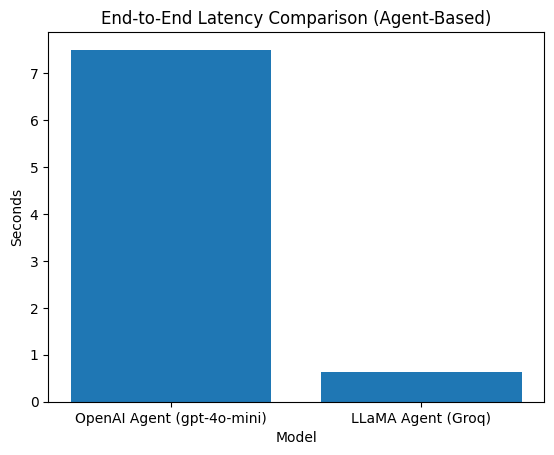

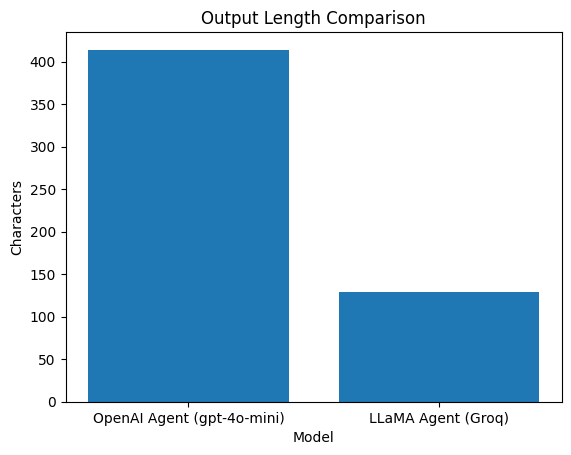

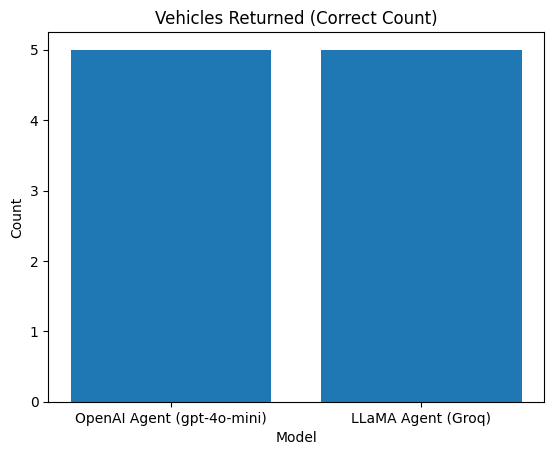

In [159]:
# ================================
# AGENT-BASED BENCHMARK (FIXED)
# OpenAI Agent vs LLaMA Agent
# ================================

import time
import pandas as pd
import matplotlib.pyplot as plt
import asyncio


# --------------------------------
# CONFIG
# --------------------------------
TEST_PROMPT = "Find cars under $60,000. Return exactly 5 cars."


# --------------------------------
# HELPERS
# --------------------------------
def count_vehicles_from_numbered_list(text: str) -> int:
    return sum(
        1 for line in text.splitlines()
        if line.strip().startswith(tuple(f"{i}." for i in range(1, 11)))
    )


# --------------------------------
# 1. OPENAI AGENT RUN (ASYNC FIX)
# --------------------------------
async def _run_openai_agent_async():
    start = time.time()

    result = await Runner.run(
        budget_recommendation_agent,
        TEST_PROMPT
    )

    latency = time.time() - start
    output = result.final_output

    return {
        "provider": "OpenAI Agent (gpt-4o-mini)",
        "latency_seconds": round(latency, 4),
        "output_length_chars": len(output),
        "num_vehicles_returned": count_vehicles_from_numbered_list(output),
        "output": output,
        "error": False
    }


def run_openai_agent():
    return asyncio.run(_run_openai_agent_async())


# --------------------------------
# 2. LLaMA AGENT RUN (GROQ)
# --------------------------------
def run_llama_agent():
    start = time.time()

    output = run_llama_budget_agent(TEST_PROMPT)

    latency = time.time() - start

    return {
        "provider": "LLaMA Agent (Groq)",
        "latency_seconds": round(latency, 4),
        "output_length_chars": len(output),
        "num_vehicles_returned": count_vehicles_from_numbered_list(output),
        "output": output,
        "error": False
    }


# --------------------------------
# 3. RUN BENCHMARK
# --------------------------------
results = [
    run_openai_agent(),
    run_llama_agent()
]

df = pd.DataFrame(results)

print(df[[
    "provider",
    "latency_seconds",
    "output_length_chars",
    "num_vehicles_returned"
]])


# --------------------------------
# 4. PLOTS
# --------------------------------

# Latency Plot
plt.figure()
plt.bar(df["provider"], df["latency_seconds"])
plt.title("End-to-End Latency Comparison (Agent-Based)")
plt.ylabel("Seconds")
plt.xlabel("Model")
plt.show()

# Output Length Plot
plt.figure()
plt.bar(df["provider"], df["output_length_chars"])
plt.title("Output Length Comparison")
plt.ylabel("Characters")
plt.xlabel("Model")
plt.show()

# Vehicles Returned Plot
plt.figure()
plt.bar(df["provider"], df["num_vehicles_returned"])
plt.title("Vehicles Returned (Correct Count)")
plt.ylabel("Count")
plt.xlabel("Model")
plt.show()
